# Linear Regression: NumPy, Scikit-Learn, Gradient Descent

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

## Data

In [12]:
path = "C:\\Users\\olowo\\Downloads\\tvmarketing.csv"
adv = pd.read_csv(path)

In [13]:
adv.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


<Axes: xlabel='TV', ylabel='Sales'>

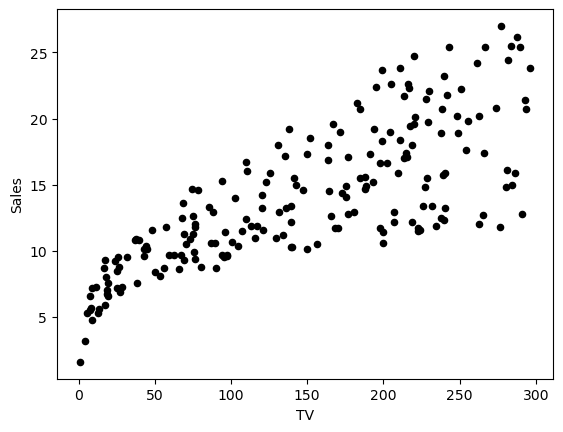

In [14]:
adv.plot(x='TV', y='Sales', kind='scatter', c='black')

In [15]:
X = adv['TV']
Y = adv['Sales']

## NumPy

In [16]:
m_numpy, b_numpy = np.polyfit(X, Y, 1)

print(f"Linear regression with NumPy. Slope: {m_numpy}. Intercept: {b_numpy}")

Linear regression with NumPy. Slope: 0.04753664043301976. Intercept: 7.032593549127698


In [17]:
def pred_numpy(m, b, X):
    Y = m*X+b
    return Y

In [18]:
X_pred = np.array([50, 120, 280])
Y_pred_numpy = pred_numpy(m_numpy, b_numpy, X_pred)

print(f"TV marketing expenses:\n{X_pred}")
print(f"Predictions of sales using NumPy linear regression:\n{Y_pred_numpy}")

TV marketing expenses:
[ 50 120 280]
Predictions of sales using NumPy linear regression:
[ 9.40942557 12.7369904  20.34285287]


## Scikit-Learn

In [19]:
lr_sklearn = LinearRegression()

In [20]:
print(f"Shape of X array: {X.shape}")
print(f"Shape of Y array: {Y.shape}")

try:
    lr_sklearn.fit(X, Y)
except ValueError as err:
    print(err)

Shape of X array: (200,)
Shape of Y array: (200,)
Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.


In [23]:
X_sklearn = np.array(X).reshape(-1, 1)
Y_sklearn = np.array(Y).reshape(-1, 1)

print(f"Shape of new X array: {X_sklearn.shape}")
print(f"Shape of new Y array: {Y_sklearn.shape}")

Shape of new X array: (200, 1)
Shape of new Y array: (200, 1)


In [24]:
lr_sklearn.fit(X_sklearn, Y_sklearn)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
m_sklearn = lr_sklearn.coef_
b_sklearn = lr_sklearn.intercept_

print(f"Linear regression using Scikit-Learn. Slope: {m_sklearn}. Intercept: {b_sklearn}")

Linear regression using Scikit-Learn. Slope: [[0.04753664]]. Intercept: [7.03259355]


In [26]:
def pred_sklearn(X, lr_sklearn):
    X_2D = X[:, np.newaxis]
    Y = lr_sklearn.predict(X_2D)
    return Y

In [27]:
Y_pred_sklearn = pred_sklearn(X_pred, lr_sklearn)

print(f"TV marketing expenses:\n{X_pred}")
print(f"Predictions of sales using Scikit_Learn linear regression:\n{Y_pred_sklearn.T}")

TV marketing expenses:
[ 50 120 280]
Predictions of sales using Scikit_Learn linear regression:
[[ 9.40942557 12.7369904  20.34285287]]


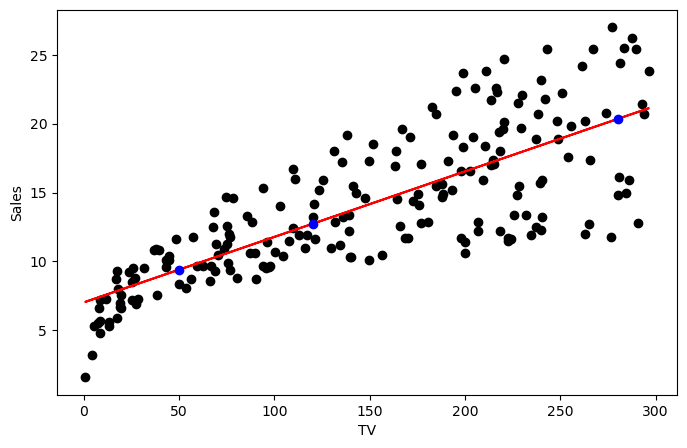

In [28]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
ax.plot(X, Y, 'o', color='black')
ax.set_xlabel('TV')
ax.set_ylabel('Sales')

ax.plot(X, m_sklearn[0][0]*X+b_sklearn[0], color='red')
ax.plot(X_pred, Y_pred_sklearn, 'o', color='blue')

## Gradient Descent

In [29]:
X_norm = (X - np.mean(X))/np.std(X)
Y_norm = (Y - np.mean(Y))/np.std(Y)

In [30]:
def E(m, b, X, Y):
    return 1/(2*len(Y))*np.sum((m*X + b - Y)**2)

In [33]:
def dEdm(m, b, X, Y):
    res = 1/len(X)*np.dot(m*X + b - Y, X)
    return res
    

def dEdb(m, b, X, Y):
    res = 1/len(X)*np.sum((m*X + b - Y))
    return res


In [34]:
def gradient_descent(dEdm, dEdb, m, b, X, Y, learning_rate = 0.001, num_iterations = 1000, print_cost=False):
    for iteration in range(num_iterations):
        m_new = m - learning_rate*dEdm(m,b,X,Y)
        b_new = b - learning_rate*dEdb(m,b,X,Y)
        m = m_new
        b = b_new
        if print_cost:
            print (f"Cost after iteration {iteration}: {E(m, b, X, Y)}")
        
    return m, b

In [35]:
print(gradient_descent(dEdm, dEdb, 0, 0, X_norm, Y_norm))
print(gradient_descent(dEdm, dEdb, 1, 5, X_norm, Y_norm, learning_rate = 0.01, num_iterations = 10))

(np.float64(0.49460408269589484), np.float64(-1.375033420458744e-16))
(np.float64(0.9791767513915026), np.float64(4.521910375044022))


In [36]:
m_initial = 0; b_initial = 0; num_iterations = 30; learning_rate = 1.2
m_gd, b_gd = gradient_descent(dEdm, dEdb, m_initial, b_initial, 
                              X_norm, Y_norm, learning_rate, num_iterations, print_cost=True)

print(f"Gradient descent result: m_min, b_min = {m_gd}, {b_gd}") 

Cost after iteration 0: 0.2062999755919659
Cost after iteration 1: 0.19455197461564464
Cost after iteration 2: 0.19408205457659175
Cost after iteration 3: 0.19406325777502964
Cost after iteration 4: 0.1940625059029672
Cost after iteration 5: 0.1940624758280847
Cost after iteration 6: 0.19406247462508938
Cost after iteration 7: 0.19406247457696957
Cost after iteration 8: 0.19406247457504477
Cost after iteration 9: 0.19406247457496775
Cost after iteration 10: 0.1940624745749647
Cost after iteration 11: 0.19406247457496456
Cost after iteration 12: 0.19406247457496456
Cost after iteration 13: 0.1940624745749646
Cost after iteration 14: 0.19406247457496456
Cost after iteration 15: 0.19406247457496456
Cost after iteration 16: 0.19406247457496456
Cost after iteration 17: 0.19406247457496456
Cost after iteration 18: 0.19406247457496456
Cost after iteration 19: 0.19406247457496456
Cost after iteration 20: 0.19406247457496456
Cost after iteration 21: 0.19406247457496456
Cost after iteration 22: 

In [37]:
X_pred = np.array([50, 120, 280])
# Use the same mean and standard deviation of the original training array X
X_pred_norm = (X_pred - np.mean(X))/np.std(X)
Y_pred_gd_norm = m_gd * X_pred_norm + b_gd
# Use the same mean and standard deviation of the original training array Y
Y_pred_gd = Y_pred_gd_norm * np.std(Y) + np.mean(Y)

print(f"TV marketing expenses:\n{X_pred}")
print(f"Predictions of sales using Scikit_Learn linear regression:\n{Y_pred_sklearn.T}")
print(f"Predictions of sales using Gradient Descent:\n{Y_pred_gd}")

TV marketing expenses:
[ 50 120 280]
Predictions of sales using Scikit_Learn linear regression:
[[ 9.40942557 12.7369904  20.34285287]]
Predictions of sales using Gradient Descent:
[ 9.40942557 12.7369904  20.34285287]
